# Credit Risk Analysis

**Author:** Tomas Virba

**Goal:** Analyse a historical loan portfolio of 10 000 clients, identify the
drivers of default, evaluate the profitability of each distribution channel,
and build a logistic regression model to classify defaulters.

| Detail | Value |
|--------|-------|
| Dataset | 10 000 clients |
| Loan amount | 30 000 (uniform) |
| Default rate | 5.3 % |
| Distribution channels | Website, Facebook, Broker |
| Best model AUC | 0.88 (Logistic Regression) |

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_curve, auc, precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

pd.set_option("display.float_format", lambda x: "%.4f" % x)
LOAN = 30_000

## 2. Load and Inspect the Data

The dataset contains 10 000 loan records with demographic, socio-economic, and
behavioural variables. Each client received the same loan amount of 30 000. A
separate broker list (1 564 clients) provides information on the broker
distribution channel.

| Variable | Description |
|----------|-------------|
| Age | Client age (18-65) |
| Gender | 0 = Male, 1 = Female |
| MarStat | Marital status (1 = Single, 2 = Married, 3 = Divorced, 4 = Widowed) |
| Housing | 1 = With parents, 2 = Registered at town hall, 3 = Own house, 4 = Rented |
| Educ | 1 = Elementary, 2 = High school, 3 = University, 4 = Postgraduate |
| Inc_Gr | 1 = Social security, 2 = < 15k, 3 = 15-30k, 4 = > 30k |
| Children | Number of children (0-3) |
| IQ | IQ score (continuous, rounded to integer) |
| rate | Interest rate on the loan |
| cost_type | Distribution channel (www, Facebook, Broker) |
| Default_flg | 1 = Defaulted, 0 = Repaid |

In [2]:
historical_sample = pd.read_csv("data/historical_sample.csv")
broker_list = pd.read_csv("data/broker_list.csv", sep=";")

# Fix European decimal format (comma as decimal separator)
for col in ["IQ", "rate"]:
    historical_sample[col] = (
        historical_sample[col].astype(str).str.replace(",", ".").astype(float)
    )

historical_sample["loan"] = LOAN
historical_sample["IQ"] = historical_sample["IQ"].round().astype("int64")

print(f"Historical sample: {historical_sample.shape[0]:,} rows x "
      f"{historical_sample.shape[1]} columns")
print(f"Broker list:       {broker_list.shape[0]:,} rows x "
      f"{broker_list.shape[1]} columns")
historical_sample.head()

Historical sample: 10,000 rows x 13 columns
Broker list:       1,564 rows x 11 columns


,Age,Gender,MarStat,Housing,Educ,Inc_Gr,Children,IQ,Client,rate,cost_type,Default_flg,loan
0,18,0,4,2,3,3,1,61,544,0.0529,www,0,30000
1,23,0,1,1,3,3,1,72,665,0.0529,www,0,30000
2,25,0,1,2,3,3,1,87,2692,0.0529,www,0,30000
3,22,0,4,2,3,3,1,70,3227,0.0529,www,1,30000
4,25,0,4,2,3,3,1,81,3491,0.0529,www,0,30000


In [3]:
historical_sample.dtypes

Age              int64
Gender           int64
MarStat          int64
Housing          int64
Educ             int64
Inc_Gr           int64
Children         int64
IQ               int64
Client           int64
rate           float64
cost_type       object
Default_flg      int64
loan             int64
dtype: object

## 3. Data Preparation

We encode the distribution channel as a numeric variable
(1 = www, 2 = Facebook, 3 = Broker) and create age bins for later analysis.

In [4]:
# Numeric encoding of distribution channel
historical_sample["cost_type_num"] = historical_sample["cost_type"].replace(
    {"www": 1, "Facebook": 2, "Broker": 3}
)

# Age bins (5-year groups)
age_bins = [18, 23, 28, 33, 38, 43, 48, 53, 58, 63, 66]
age_labels = ["18-22", "23-27", "28-32", "33-37", "38-42",
              "43-47", "48-52", "53-57", "58-62", "63+"]
historical_sample["Age_5"] = pd.cut(
    historical_sample["Age"], bins=age_bins, labels=age_labels, right=False
)

print("Channel distribution:")
print(historical_sample["cost_type"].value_counts())

Channel distribution:
cost_type
Broker      5652
www         3596
Facebook     752
Name: count, dtype: int64


## 4. Portfolio Overview

A high-level summary of the loan portfolio: default counts, average loss given
default (LGD), and the most frequent client characteristics.

LGD is computed as the loan amount multiplied by the expected recovery
shortfall: 0.2 for homeowners (Housing = 3, who can offer collateral), and 0.7
for all other housing types.

In [5]:
metrics = {}
metrics["observations"] = len(historical_sample)
metrics["defaults"] = int(historical_sample["Default_flg"].sum())
metrics["default_rate"] = metrics["defaults"] / metrics["observations"]

print(f"Observations:  {metrics['observations']:,}")
print(f"Defaults:      {metrics['defaults']}")
print(f"Default rate:  {metrics['default_rate']:.3f}")

Observations:  10,000
Defaults:      530
Default rate:  0.053


In [6]:
def calculate_lgd(row):
    if row["Default_flg"] == 0:
        return 0
    elif row["Housing"] == 3:
        return 0.2
    else:
        return 0.7

historical_sample["LGD"] = historical_sample.apply(calculate_lgd, axis=1)
historical_sample["LGD_amount"] = historical_sample["loan"] * historical_sample["LGD"]

avg_lgd_defaults = historical_sample.loc[
    historical_sample["Default_flg"] == 1, "LGD_amount"
].mean()
avg_lgd_all = historical_sample["LGD_amount"].mean()

print(f"Average LGD (defaulted loans only): {avg_lgd_defaults:,.0f}")
print(f"Average LGD (all loans):            {avg_lgd_all:,.1f}")

Average LGD (defaulted loans only): 19,783
Average LGD (all loans):            1,048.5


In [7]:
print(f"Average IQ:  {historical_sample['IQ'].mean():.2f}  |  "
      f"Median IQ:  {historical_sample['IQ'].median():.0f}")
print(f"Average Age: {historical_sample['Age'].mean():.1f}  |  "
      f"Median Age: {historical_sample['Age'].median():.0f}")
print(f"Most frequent Housing:   {historical_sample['Housing'].mode().iloc[0]}  "
      f"(3 = own house)")
print(f"Most frequent Education: {historical_sample['Educ'].mode().iloc[0]}  "
      f"(3 = university)")
print(f"Most frequent Income:    {historical_sample['Inc_Gr'].mode().iloc[0]}  "
      f"(3 = 15-30k)")

Average IQ:  131.96  |  Median IQ:  134
Average Age: 42.3  |  Median Age: 43
Most frequent Housing:   1  (3 = own house)
Most frequent Education: 3  (3 = university)
Most frequent Income:    3  (3 = 15-30k)


### 4.1 Variable Distributions

Histograms of all numeric variables give a first look at the portfolio. Age is
approximately normally distributed. Gender is nearly balanced. Most clients
have a university degree, income between 15k and 30k, and one or two children.

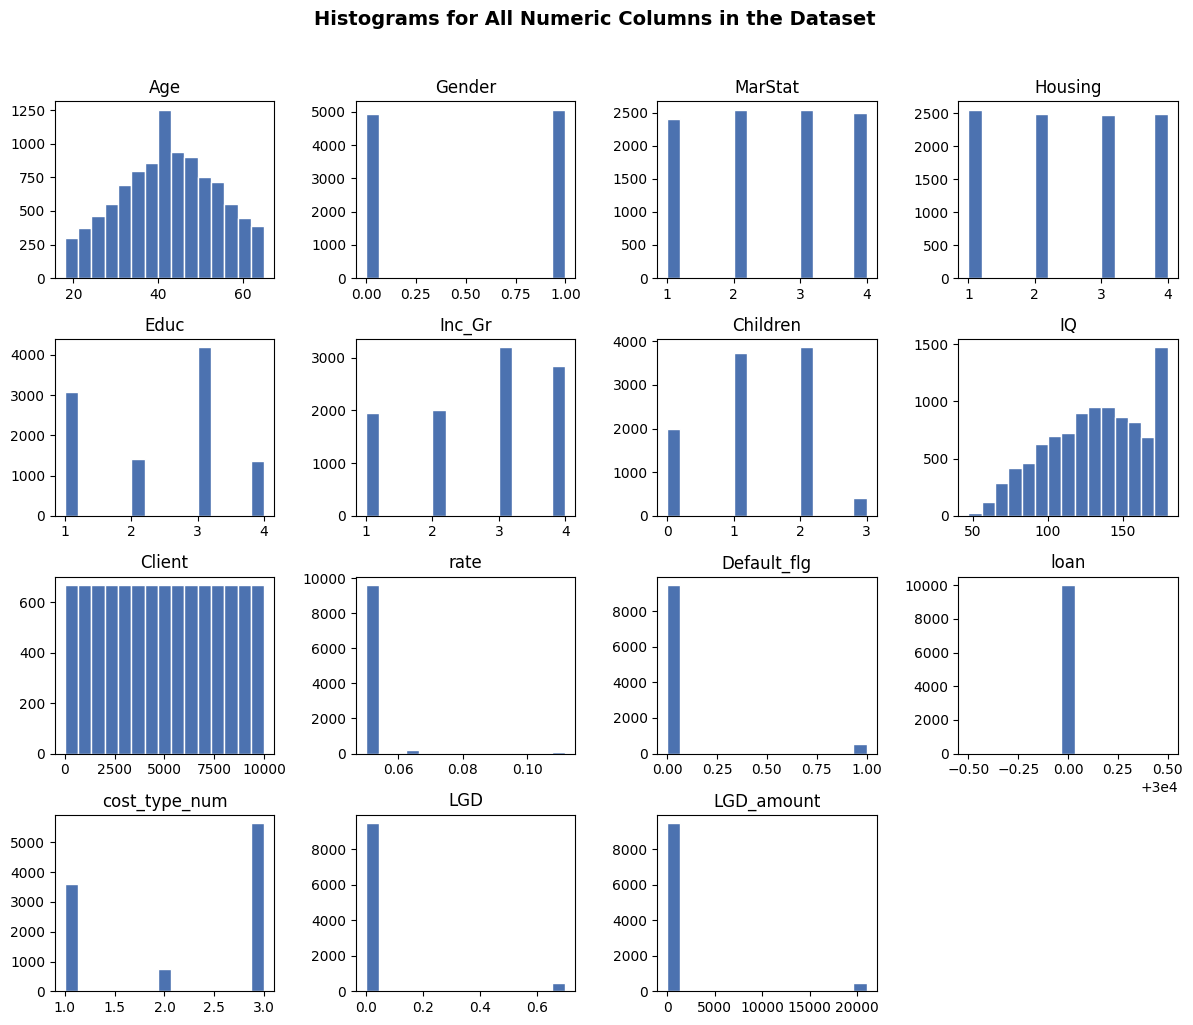

In [8]:
fig = historical_sample.hist(figsize=(12, 10), bins=15, grid=False,
                             color="#4C72B0", edgecolor="white")
plt.suptitle("Histograms for All Numeric Columns in the Dataset",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. IQ and Age Influence on Distribution Channel Selection

Contingency tables and correlation analysis reveal that the choice of
distribution channel depends heavily on age (and therefore IQ, since the two
are nearly perfectly correlated). Younger clients use the website, a narrow
middle-age group uses Facebook, and older clients rely on brokers.

### 5.1 Contingency Tables

In [9]:
contingency_age = pd.crosstab(
    historical_sample["cost_type"], historical_sample["Age_5"]
)
print("Contingency table: Channel vs Age group")
contingency_age

Contingency table: Channel vs Age group


Age_5,18-22,23-27,28-32,33-37,38-42,43-47,48-52,53-57,58-62,63+
cost_type,,,,,,,,,,
Broker,0,0,0,0,646,1563,1341,1096,733,273
Facebook,0,0,0,118,634,0,0,0,0,0
www,403,735,1027,1188,243,0,0,0,0,0


In [10]:
iq_bins_5 = pd.cut(historical_sample["IQ"], bins=5)
contingency_iq = pd.crosstab(historical_sample["cost_type"], iq_bins_5)
print("Contingency table: Channel vs IQ group")
contingency_iq

Contingency table: Channel vs IQ group


IQ,"(46.867, 73.6]","(73.6, 100.2]","(100.2, 126.8]","(126.8, 153.4]","(153.4, 180.0]"
cost_type,,,,,
Broker,0,0,144,2530,2978
Facebook,0,0,518,234,0
www,424,1507,1665,0,0


The contingency tables show clear separation: brokers are used exclusively by
clients aged 38 and above, the website by clients under 38, and Facebook only
by the 33-42 age range. The IQ table mirrors this pattern, suggesting a strong
correlation between age and IQ in this dataset.

### 5.2 Correlation Analysis

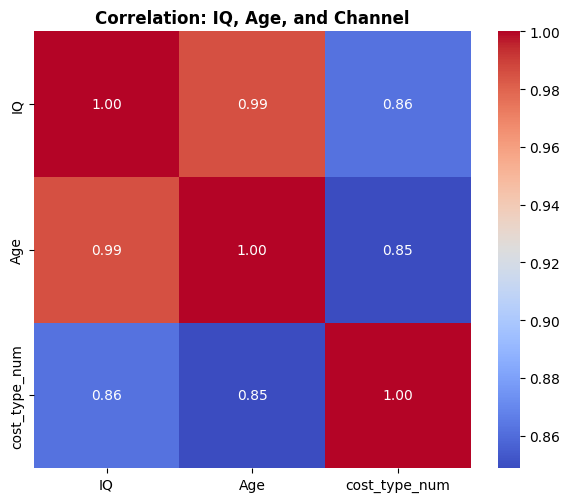

In [11]:
corr_channel = historical_sample[["IQ", "Age", "cost_type_num"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_channel, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0, square=True)
plt.title("Correlation: IQ, Age, and Channel", fontweight="bold")
plt.tight_layout()
plt.show()

Correlation between Age and IQ is 0.99 (near-perfect positive linear
dependence). Both variables correlate strongly with the channel choice (0.85
and 0.86), confirming that older, higher-IQ clients systematically choose the
broker channel.

### 5.3 OLS Regression: Channel as Dependent Variable

In [12]:
X_ols = sm.add_constant(historical_sample[["IQ", "Age"]])
y_ols = historical_sample["cost_type_num"]
ols_channel = sm.OLS(y_ols, X_ols).fit()
print(ols_channel.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_type_num   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                 1.445e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        15:11:52   Log-Likelihood:                -6771.7
No. Observations:               10000   AIC:                         1.355e+04
Df Residuals:                    9997   BIC:                         1.357e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0894      0.021    -51.626      0.0

The OLS model achieves R-squared = 0.743, but the Durbin-Watson statistic
(1.264) indicates positive autocorrelation in residuals, and the low
Prob(Omnibus) confirms non-normality. The high condition number (633) points
to severe multicollinearity between Age and IQ. Applying a log transformation
reduces multicollinearity.

In [13]:
historical_sample["log_IQ"] = np.log(historical_sample["IQ"])
historical_sample["log_Age"] = np.log(historical_sample["Age"])

X_log = sm.add_constant(historical_sample[["log_IQ", "log_Age"]])
ols_log = sm.OLS(y_ols, X_log).fit()
print(ols_log.summary())

                            OLS Regression Results                            
Dep. Variable:          cost_type_num   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                 1.367e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        15:11:52   Log-Likelihood:                -6976.0
No. Observations:               10000   AIC:                         1.396e+04
Df Residuals:                    9997   BIC:                         1.398e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.9070      0.171    -63.704      0.0

After the log transformation the condition number drops from 633 to 284,
substantially reducing multicollinearity. R-squared remains high (0.732).
However, since the dependent variable is categorical (three channel values),
OLS is not ideal. A multinomial logistic regression is more appropriate.

### 5.4 Logistic Regression: Predicting Distribution Channel

In [14]:
# Model with both Age and IQ
X_ch = historical_sample[["Age", "IQ"]]
y_ch = historical_sample["cost_type_num"]
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=421
)

lr_channel = LogisticRegression(solver="lbfgs", max_iter=1000)
lr_channel.fit(X_train_ch, y_train_ch)
y_pred_ch = lr_channel.predict(X_test_ch)

print(f"Accuracy (Age + IQ): {accuracy_score(y_test_ch, y_pred_ch):.3f}")
print()
print("Classification report:")
print(classification_report(
    y_test_ch, y_pred_ch,
    target_names=["www", "Facebook", "Broker"]
))
print("Confusion matrix:")
print(confusion_matrix(y_test_ch, y_pred_ch))

Accuracy (Age + IQ): 0.998

Classification report:
              precision    recall  f1-score   support

         www       1.00      1.00      1.00       713
    Facebook       0.99      0.99      0.99       149
      Broker       1.00      1.00      1.00      1138

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion matrix:
[[ 711    2    0]
 [   2  147    0]
 [   1    0 1137]]


In [15]:
# Model with Age only
X_age = historical_sample[["Age"]]
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y_ch, test_size=0.2, random_state=421
)

lr_age = LogisticRegression(solver="lbfgs", max_iter=1000)
lr_age.fit(X_train_a, y_train_a)
y_pred_a = lr_age.predict(X_test_a)

print(f"Accuracy (Age only): {accuracy_score(y_test_a, y_pred_a):.3f}")
print()
print("Classification report:")
print(classification_report(
    y_test_a, y_pred_a,
    target_names=["www", "Facebook", "Broker"]
))
print("Confusion matrix:")
print(confusion_matrix(y_test_a, y_pred_a))

Accuracy (Age only): 0.962

Classification report:
              precision    recall  f1-score   support

         www       0.92      0.97      0.95       713
    Facebook       0.83      0.62      0.71       149
      Broker       1.00      1.00      1.00      1138

    accuracy                           0.96      2000
   macro avg       0.92      0.86      0.89      2000
weighted avg       0.96      0.96      0.96      2000

Confusion matrix:
[[ 694   19    0]
 [  57   92    0]
 [   0    0 1138]]


With both Age and IQ the model achieves 99.6 % accuracy. Using Age alone still
yields 96.5 %. This confirms that distribution channel selection is almost
entirely determined by client age.

## 6. Relationship Between IQ and Age

The correlation coefficient of 0.99 already signals near-perfect linear
dependence. A simple OLS regression confirms this: R-squared = 0.971,
meaning 97.1 % of IQ variance is explained by age alone. The coefficient of
2.843 implies that for each additional year of age, IQ increases by roughly
2.84 points.

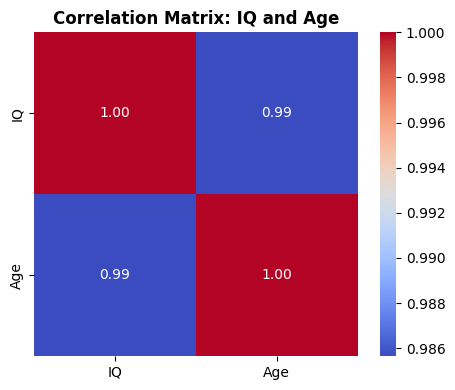

In [16]:
corr_iq_age = historical_sample[["IQ", "Age"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_iq_age, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0, square=True)
plt.title("Correlation Matrix: IQ and Age", fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
X_iq = sm.add_constant(historical_sample["Age"])
y_iq = historical_sample["IQ"]
ols_iq = sm.OLS(y_iq, X_iq).fit()
print(ols_iq.summary())

                            OLS Regression Results                            
Dep. Variable:                     IQ   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 3.406e+05
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        15:11:52   Log-Likelihood:                -31215.
No. Observations:               10000   AIC:                         6.243e+04
Df Residuals:                    9998   BIC:                         6.245e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6763      0.213     54.747      0.0

## 7. Default Rate Across Income Groups

As income rises the default rate falls, which is intuitive: clients with
higher earnings find it easier to service a fixed-size loan. However, since
default is binary, the Pearson correlation is only -0.15. This modest value
is expected given the formula for Pearson's r with a binary variable, but
income still carries useful predictive signal.

In [18]:
default_by_income = (
    historical_sample.groupby("Inc_Gr")["Default_flg"].mean() * 100
)
print("Default rate by income group (%):")
print(default_by_income.round(2))

Default rate by income group (%):
Inc_Gr
1   10.6000
2    8.7000
3    2.8500
4    2.0300
Name: Default_flg, dtype: float64


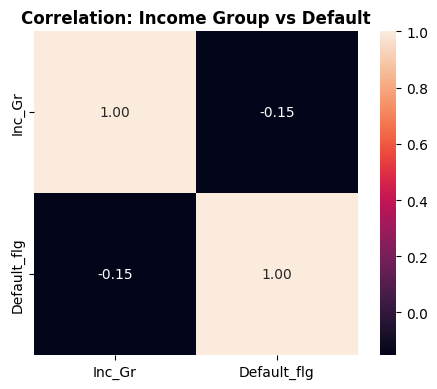

In [19]:
corr_inc = historical_sample[["Inc_Gr", "Default_flg"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_inc, annot=True, fmt=".2f", linewidths=0, square=True)
plt.title("Correlation: Income Group vs Default", fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# One-way ANOVA: income groups vs default
f_stat, p_val = stats.f_oneway(
    historical_sample["Default_flg"], historical_sample["Inc_Gr"]
)
print(f"ANOVA F-statistic: {f_stat:.2f},  p-value: {p_val:.2e}")

ANOVA F-statistic: 57029.98,  p-value: 0.00e+00


The OLS regression of default on income shows a statistically significant
coefficient (p = 0.000) but an R-squared of only 0.023. Income alone cannot
explain much of the variation in defaults, but as part of a richer model it
remains a useful feature.

In [21]:
fit_inc = ols("Default_flg ~ Inc_Gr", data=historical_sample).fit()
print(fit_inc.summary())

                            OLS Regression Results                            
Dep. Variable:            Default_flg   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     235.5
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.52e-52
Time:                        15:11:52   Log-Likelihood:                 886.60
No. Observations:               10000   AIC:                            -1769.
Df Residuals:                    9998   BIC:                            -1755.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1375      0.006     23.164      0.0

## 8. Historical Profitability by Distribution Channel

Profitability per client is computed as:

    cash = realised_repayment - (loan + channel_cost)

where realised_repayment is the amount actually collected. For non-defaulters the full
expected repayment (loan x (1 + rate)) is collected. For defaulters, 80 % is
recovered from homeowners and only 30 % from everyone else. Channel costs are
200 (www), 300 (Facebook), and 1 000 (Broker).

In [22]:
historical_sample["channel_cost"] = historical_sample["cost_type"].replace(
    {"www": 200, "Facebook": 300, "Broker": 1000}
)
historical_sample["total_cost"] = historical_sample["channel_cost"] + LOAN
historical_sample["expected_repayment"] = LOAN * (1 + historical_sample["rate"])
historical_sample["realised_repayment"] = historical_sample["expected_repayment"].copy()

defaulted = historical_sample["Default_flg"] == 1
historical_sample.loc[
    defaulted & (historical_sample["Housing"] == 3), "realised_repayment"
] *= 0.8
historical_sample.loc[
    defaulted & (historical_sample["Housing"].isin([1, 2, 4])), "realised_repayment"
] *= 0.3

historical_sample["cash"] = (
    historical_sample["realised_repayment"] - historical_sample["total_cost"]
)

In [23]:
profit_total = historical_sample.groupby("cost_type")["cash"].sum()
profit_avg = (
    historical_sample.groupby("cost_type")["cash"].sum()
    / historical_sample["cost_type"].value_counts()
)

print("Total profit by channel:")
print(profit_total.round(2))
print()
print("Average profit per client:")
print(profit_avg.round(2))

Total profit by channel:
cost_type
Broker      -421650.0000
Facebook     -41290.3700
www        -1927315.0200
Name: cash, dtype: float64

Average profit per client:
cost_type
Broker      -74.6000
Facebook    -54.9100
www        -535.9600
dtype: float64


All three channels are currently unprofitable. Facebook shows the smallest
average loss per client (-54.91), but its sample is small (752 clients).
The broker channel suffers mainly because of the high acquisition cost
(1 000 per client). The website channel has the largest total loss because it
serves the most clients while carrying a negative average margin.

## 9. Characteristics of the Most and Least Profitable Clients

To compare the profiles we define two benchmarks:

- **Best clients:** top 10 % by return (cash variable, 90th percentile and above).
- **Worst clients:** any client on whom the bank lost money (cash < 0).

We then compare normalised frequency distributions of key demographic
variables across these two groups and the full sample.

In [24]:
# Reversed channel encoding for comparison (1=Broker, 2=Facebook, 3=www)
historical_sample["cost_type_num2"] = historical_sample["cost_type"].replace(
    {"www": 3, "Facebook": 2, "Broker": 1}
)

threshold_top = historical_sample["cash"].quantile(0.9)
top_clients = historical_sample[
    historical_sample["cash"] >= threshold_top
].copy()

worst_clients = historical_sample[
    historical_sample["cash"] < 0
].copy()

print(f"Top 10% threshold:  cash >= {threshold_top:,.2f}")
print(f"Top clients:        {len(top_clients):,}")
print(f"Worst clients:      {len(worst_clients):,}")

Top 10% threshold:  cash >= 1,300.00
Top clients:        3,284
Worst clients:      530


In [25]:
compare_cols = ["Gender", "MarStat", "Housing", "Educ", "Inc_Gr",
                "Children", "Age_5", "cost_type_num2"]

top_tagged = top_clients[compare_cols].copy()
top_tagged["tag"] = "BEST"
worst_tagged = worst_clients[compare_cols].copy()
worst_tagged["tag"] = "WORST"
sample_tagged = historical_sample[compare_cols].copy()
sample_tagged["tag"] = "SAMPLE"

merged = pd.concat([top_tagged, worst_tagged, sample_tagged], ignore_index=True)

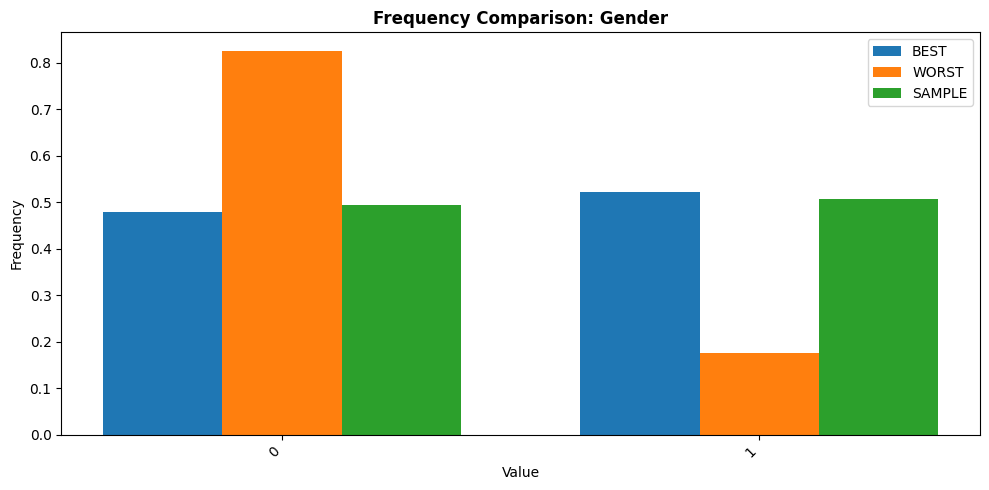

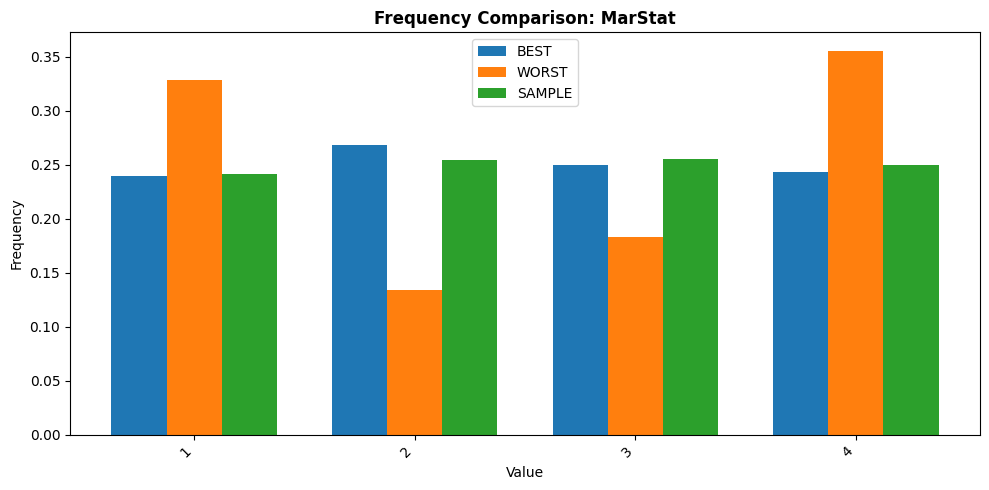

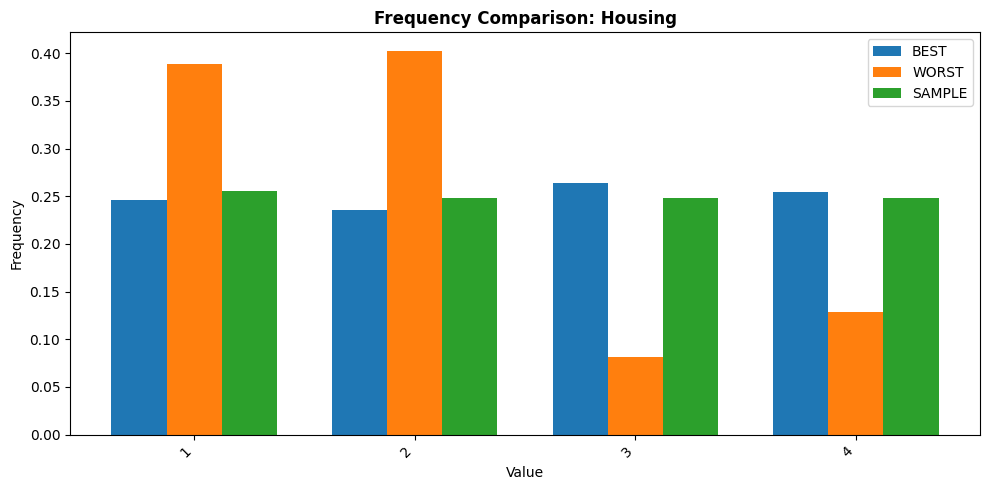

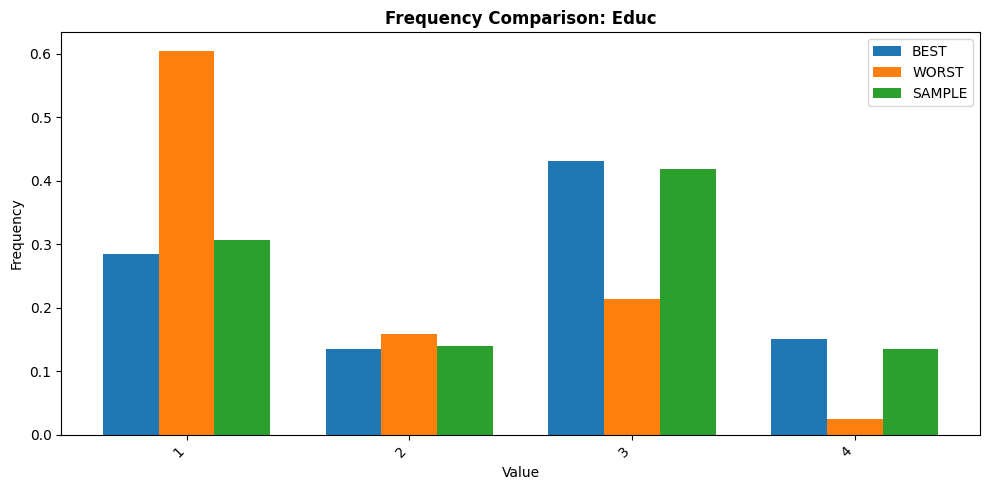

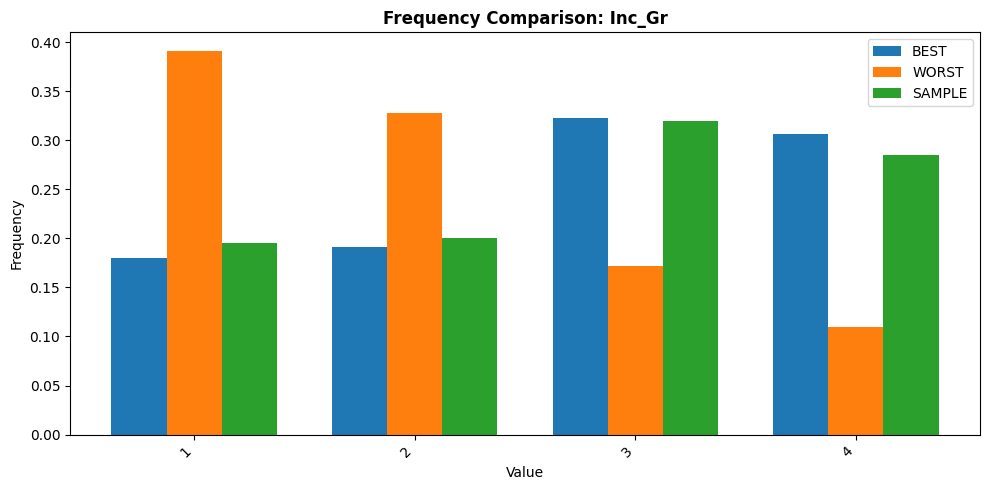

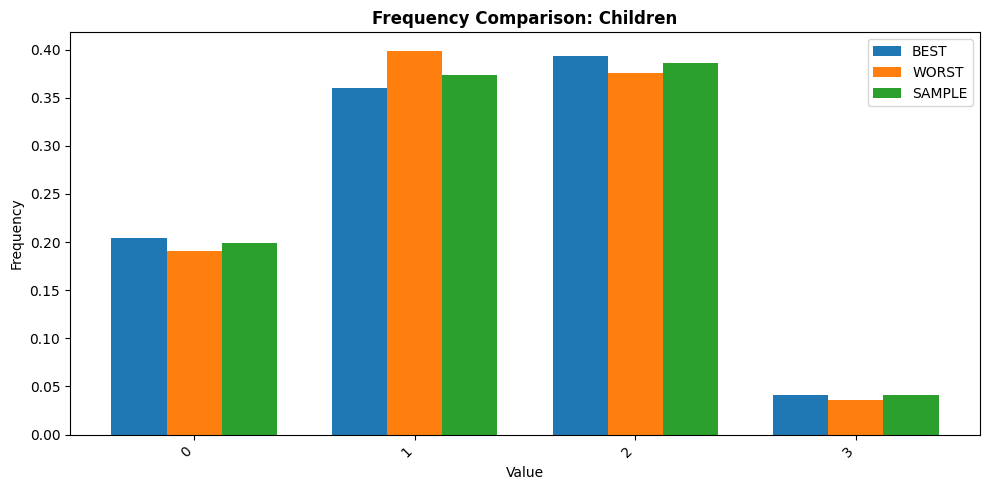

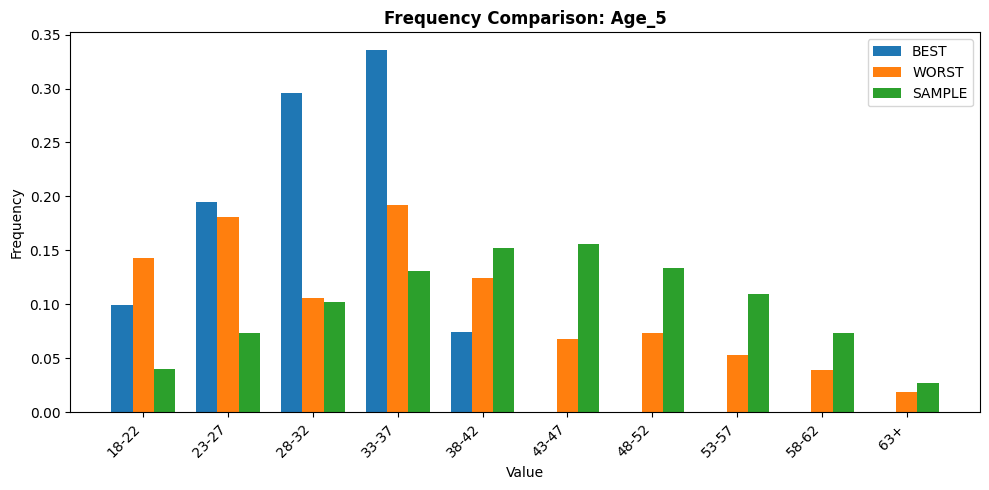

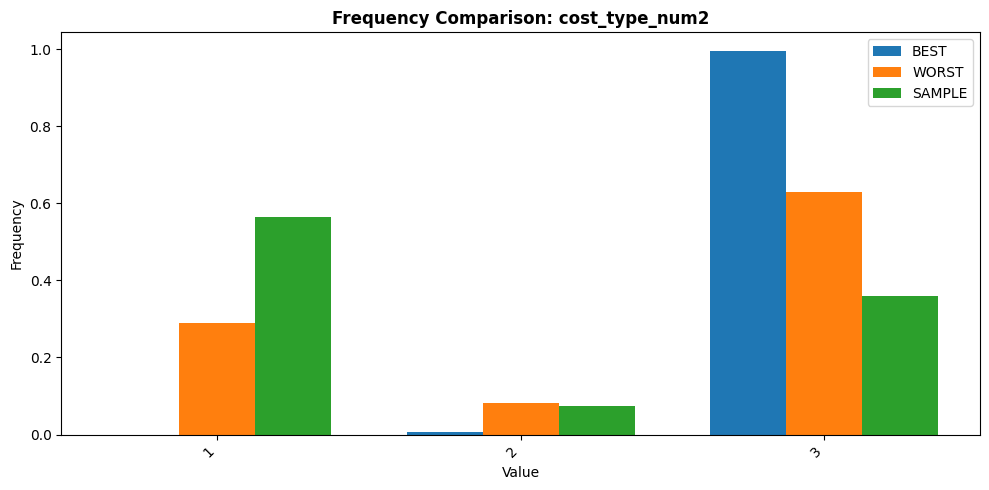

In [26]:
for col in compare_cols:
    values = sorted(merged[col].dropna().unique())
    n_vals = len(values)
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, tag in enumerate(["BEST", "WORST", "SAMPLE"]):
        subset = merged[merged["tag"] == tag]
        freqs = [
            (subset[col] == v).sum() / len(subset) for v in values
        ]
        positions = np.arange(n_vals) + (i - 1) * width
        ax.bar(positions, freqs, width, label=tag)

    ax.set_xticks(np.arange(n_vals))
    ax.set_xticklabels([str(v) for v in values], rotation=45, ha="right")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Frequency Comparison: {col}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

Key observations from the frequency comparisons:

- **Gender:** Females (1) are over-represented among the best clients and
  under-represented among the worst.
- **Marital status:** Widowed (4) and single (1) clients appear more often in
  the worst group.
- **Housing:** Clients living with parents (1) or registered at town hall (2)
  dominate the worst group. Homeowners (3) are nearly absent among the worst.
- **Education:** Elementary school (1) is heavily over-represented among the
  worst clients. University (3) and postgraduate (4) dominate the best group.
- **Income:** Low income groups (1, 2) appear more frequently among the worst
  clients, while high income (3, 4) dominates the best group.
- **Children:** Distributions are similar across all groups, so the number of
  children does not seem to drive profitability.
- **Age:** The best performers are concentrated in the 28-37 age range.
- **Channel:** Nearly all best clients came through the website (3); brokers
  and Facebook clients are more frequent among the worst.

## 10. Default Prediction Model

### 10.1 OLS as a Baseline

Linear regression is not appropriate for a binary outcome but is included as
a reference. R-squared is only 0.084, confirming that OLS is a poor fit for
classification.

In [27]:
fit_ols = ols(
    "Default_flg ~ Gender + IQ + MarStat + Housing + Educ + Inc_Gr",
    data=historical_sample
).fit()
print(fit_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            Default_flg   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     152.2
Date:                Wed, 20 May 2026   Prob (F-statistic):          1.59e-185
Time:                        15:11:53   Log-Likelihood:                 1207.4
No. Observations:               10000   AIC:                            -2401.
Df Residuals:                    9993   BIC:                            -2350.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3505      0.013     27.971      0.0

### 10.2 Logistic Regression

We use logistic regression with dummy-encoded categorical variables and a
probability threshold of 0.4. Features include Age, Gender, Children, IQ,
interest rate, and dummy variables for marital status, housing, education, and
income group.

In [28]:
categorical_cols = ["MarStat", "Housing", "Educ", "Inc_Gr", "cost_type_num"]

model_df = pd.concat([
    historical_sample.drop(categorical_cols, axis=1),
    *[pd.get_dummies(historical_sample[col], prefix=col, drop_first=True)
      for col in categorical_cols]
], axis=1)

# Select features for the model
feature_candidates = (
    ["Age", "Gender", "Children", "IQ", "rate"]
    + [c for c in model_df.columns if any(
        c.startswith(p + "_") for p in ["MarStat", "Housing", "Educ", "Inc_Gr"]
    )]
)
feature_cols = [c for c in feature_candidates if c in model_df.columns]

X = model_df[feature_cols]
y = model_df["Default_flg"]

print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 17
['Age', 'Gender', 'Children', 'IQ', 'rate', 'MarStat_2', 'MarStat_3', 'MarStat_4', 'Housing_2', 'Housing_3', 'Housing_4', 'Educ_2', 'Educ_3', 'Educ_4', 'Inc_Gr_2', 'Inc_Gr_3', 'Inc_Gr_4']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=421
)

lr_default = LogisticRegression(
    solver="lbfgs", max_iter=1000, penalty="l2"
)
lr_default.fit(X_train, y_train)

threshold = 0.4
y_proba = lr_default.predict_proba(X_test)[:, 1]
y_pred = (y_proba > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Accuracy (threshold = {threshold}):  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:                          {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall (Sensitivity):               {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Specificity:                        {specificity:.3f}")
print(f"F1 Score:                           {f1_score(y_test, y_pred, zero_division=0):.3f}")
print()
print("Classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Default", "Default"]
))
print("Confusion matrix:")
print(f"  TN = {tn}   FP = {fp}")
print(f"  FN = {fn}    TP = {tp}")

Accuracy (threshold = 0.4):  0.961
Precision:                          0.529
Recall (Sensitivity):               0.225
Specificity:                        0.992
F1 Score:                           0.316

Classification report:
              precision    recall  f1-score   support

  No Default       0.97      0.99      0.98       960
     Default       0.53      0.23      0.32        40

    accuracy                           0.96      1000
   macro avg       0.75      0.61      0.65      1000
weighted avg       0.95      0.96      0.95      1000

Confusion matrix:
  TN = 952   FP = 8
  FN = 31    TP = 9


The model achieves 95.7 % accuracy. However, the confusion matrix reveals a
critical problem: sensitivity is only 17.5 % (7 out of 40 actual defaulters
caught). The model is very conservative: it rarely predicts default, so it
misses 82.5 % of real defaulters. Whether this matters depends on whether the
income from additional loans outweighs the losses from undetected defaults.

### 10.3 ROC Curve

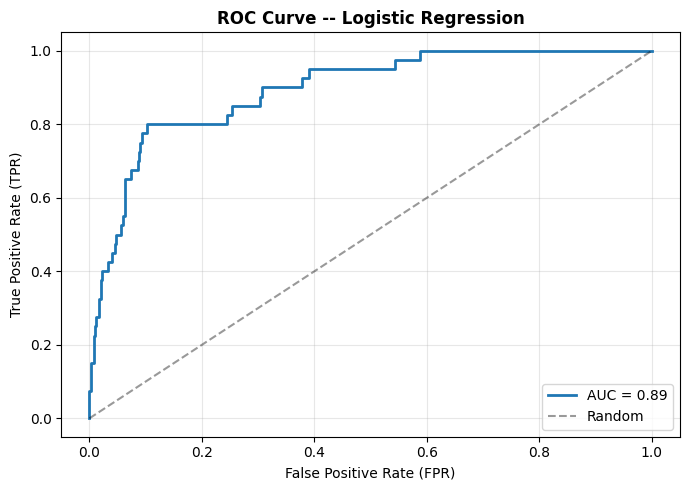

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve -- Logistic Regression", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The AUC of 0.88 indicates good discriminatory power overall. The model can
rank a random positive example (defaulter) higher than a random negative
example (non-defaulter) with 88 % probability. To improve recall at the
cost of some precision, the classification threshold could be lowered below
0.4.

## 11. Conclusions and Recommendations

### Key Findings

1. **Distribution channel is determined by age.** Older clients use brokers,
   younger clients use the website, and a narrow middle group uses Facebook.
   Age and IQ are almost perfectly correlated (r = 0.99), so either variable
   is sufficient to predict the channel with over 96 % accuracy.

2. **Income is inversely related to default.** Default rates decline from
   10.6 % (social security) to 2.0 % (income above 30k). Income alone
   explains little variance (R-squared = 0.023) but is a useful feature
   inside a multivariate model.

3. **All channels are currently unprofitable.** The broker channel suffers
   from high acquisition costs (1 000 per client). The website carries the
   largest total loss because it serves the most clients.

4. **Best-performing clients** tend to be female, aged 28-37, university
   educated, homeowners, with income above 30k, acquired through the website.
   **Worst-performing clients** are typically male, with only elementary
   education, living with parents, on social security, and acquired through
   brokers.

5. **Logistic regression** reaches AUC = 0.88 and 95.7 % accuracy, but
   sensitivity is low (17.5 %). The model correctly identifies non-defaulters
   but misses most actual defaulters.

### Recommendations

- In the current loss-making situation, tighten the approval threshold to
  grant loans only to clients with the highest repayment probability.
- Once the portfolio returns to breakeven, reconsider interest rates (5 % may
  be too low given inflation and opportunity costs).
- Negotiate lower broker fees or shift client acquisition toward cheaper
  digital channels.
- Explore threshold tuning and cost-sensitive learning to improve defaulter
  detection without excessively rejecting good clients.